<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/DL/NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
!pip install opendatasets

In [50]:
import opendatasets as od

In [51]:
od.download('https://www.kaggle.com/datasets/aakash50897/churn-modellingcsv')

Skipping, found downloaded files in "./churn-modellingcsv" (use force=True to force download)


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
df = pd.read_csv('/content/churn-modellingcsv/Churn_Modelling.csv')

In [54]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
3347,3348,15694510,Ifeanyichukwu,725,France,Male,45,1,129855.32,1,0,0,24218.65,0
8303,8304,15728333,McBurney,521,France,Male,43,8,0.00,1,1,1,93180.09,0
3500,3501,15675675,Slate,850,France,Female,32,5,106290.64,1,1,0,121982.73,0
509,510,15598883,King,599,Spain,Female,37,2,0.00,2,1,1,143739.29,0
3904,3905,15566633,Freeman,698,Germany,Male,55,8,155059.10,2,1,1,144584.29,0


In [55]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

In [56]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [57]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [58]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [59]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [60]:
df.sample(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
1564,773,42,8,152324.66,2,1,0,171733.22,0,True,False,False
4732,638,53,1,123916.67,1,1,0,16657.68,1,True,False,False
4488,716,44,6,155114.90,1,0,0,133871.83,0,False,False,False
6180,579,37,4,0.00,2,1,1,32246.63,0,False,True,True
262,557,32,6,184686.41,2,1,0,14956.44,0,False,False,False


In [61]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

In [62]:
from sklearn.model_selection import train_test_split

In [63]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
scaler = StandardScaler()

In [66]:
X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [67]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [68]:
model = Sequential()

model.add(Dense(11,activation='sigmoid'))
model.add(Dense(11,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))


In [69]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [70]:
model.compile(optimizer='Adam',loss = 'binary_crossentropy', metrics=['accuracy'])

In [71]:
history = model.fit(X_train, y_train, batch_size = 50, epochs=100, verbose=1, validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5871 - loss: 0.6555 - val_accuracy: 0.7969 - val_loss: 0.5150
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7879 - loss: 0.5186 - val_accuracy: 0.7969 - val_loss: 0.4985
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7991 - loss: 0.4978 - val_accuracy: 0.7969 - val_loss: 0.4975
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7981 - loss: 0.4978 - val_accuracy: 0.7969 - val_loss: 0.4968
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7890 - loss: 0.5094 - val_accuracy: 0.7969 - val_loss: 0.4964
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7970 - loss: 0.4982 - val_accuracy: 0.7969 - val_loss: 0.4960
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7980 - loss: 0.4980 - val_accuracy: 0.7969 - val_loss: 0.4957
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7946 - loss: 0.5024 - val_accu

In [72]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [73]:
y_pred

array([[0.25089946],
       [0.25089946],
       [0.24834411],
       ...,
       [0.24834411],
       [0.22933395],
       [0.25089946]], dtype=float32)

In [78]:
y_pred = y_pred.argmax(axis=-1)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [79]:
from sklearn.metrics import accuracy_score

In [80]:
accuracy_score(y_test,y_pred)

0.7975

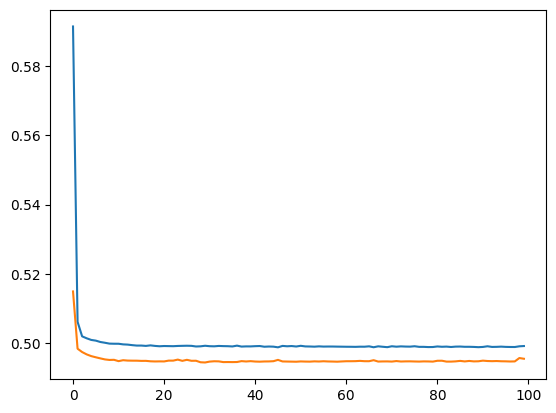

In [81]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [84]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [88]:
history.history['loss']

[0.5913150906562805,
 0.5062317848205566,
 0.5020464658737183,
 0.5014852285385132,
 0.5010148882865906,
 0.5008139610290527,
 0.5004218816757202,
 0.5002018213272095,
 0.4999536871910095,
 0.4999198615550995,
 0.49991393089294434,
 0.4997352957725525,
 0.49967026710510254,
 0.49951228499412537,
 0.49938905239105225,
 0.49939388036727905,
 0.4992946684360504,
 0.49944889545440674,
 0.4992925226688385,
 0.4991934597492218,
 0.4992617666721344,
 0.4992372989654541,
 0.49921202659606934,
 0.4992809295654297,
 0.4993137717247009,
 0.4993413984775543,
 0.49931031465530396,
 0.49912911653518677,
 0.49917590618133545,
 0.49933531880378723,
 0.4992105960845947,
 0.4991756081581116,
 0.499283105134964,
 0.49923428893089294,
 0.49921026825904846,
 0.49913886189460754,
 0.4993706941604614,
 0.49909982085227966,
 0.49915584921836853,
 0.4991503655910492,
 0.499218225479126,
 0.49926120042800903,
 0.4990575909614563,
 0.49911725521087646,
 0.49907711148262024,
 0.49888545274734497,
 0.4992940425872

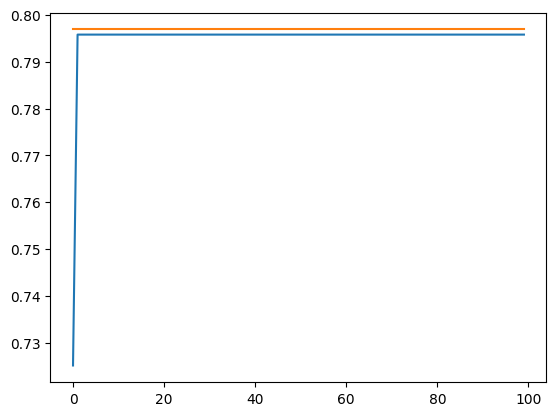

In [89]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])